# Article 2: Explainable AI for Trusted Irrigation Predictions

## Data Preprocessing and Exploratory Analysis

**Research Objective:** Transform black-box LSTM irrigation predictions into interpretable, explainable models that reveal WHY irrigation decisions are made.

**Dataset:** Greenhouse sensor data from Article 1 (Ghazouani et al., 2023)
- Period: January 17, 2022 - September 15, 2022
- Frequency: Every 5 minutes
- Samples: ~947,683 records
- Crop: Tomatoes

**Sensors:**
1. `humidity` - Indoor humidity (%)
2. `temperature` - Indoor temperature (°C)
3. `humiditysol` - Soil moisture (TARGET) (%)
4. `temperaturesol` - Soil temperature (°C)
5. `co2` - CO2 concentration (ppm)
6. `lumière` - Illumination intensity (lux)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.3.4


## 2. Load Dataset

In [2]:
data_path = '../../data.csv'
df = pd.read_csv(data_path, encoding='latin-1')

print(f"Dataset loaded successfully!")
print(f"Total samples: {len(df):,}")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Total samples: 947,682

Dataset shape: (947682, 8)

First 5 rows:


,Id,humidity,temperature,humiditysol,temperaturesol,co2,lumière,date
0,2,73.4,24.2,0,10,71.82,0,2022-04-18 12:54:36
1,3,80.7,24.2,8,10,47.17,0,2022-04-18 12:55:36
2,4,90.5,24.1,3,10,113.27,1,2022-04-18 12:56:36
3,5,0.0,0.0,7,10,44.00,1,2022-04-18 12:57:38
4,6,85.6,25.7,6,10,101.62,1,2022-04-18 12:58:38


## 3. Exploratory Data Analysis

In [3]:
print("Dataset Information:")
print(df.info())
print("\n" + "="*50)
print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947682 entries, 0 to 947681
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              947682 non-null  int64  
 1   humidity        947682 non-null  float64
 2   temperature     947682 non-null  float64
 3   humiditysol     947682 non-null  int64  
 4   temperaturesol  947682 non-null  int64  
 5   co2             947682 non-null  float64
 6   lumière         947682 non-null  int64  
 7   date            947682 non-null  object 
dtypes: float64(3), int64(4), object(1)
memory usage: 57.8+ MB
None


Statistical Summary:


,Id,humidity,temperature,humiditysol,temperaturesol,co2,lumière
count,947682.000000,947682.000000,947682.000000,947682.000000,947682.0,947682.000000,947682.000000
mean,473842.500000,56.762448,22.831257,41.955232,10.0,109.464103,0.996942
std,273572.373241,6.782545,3.257702,13.178130,0.0,122.567513,0.055214
min,2.000000,0.000000,0.000000,-85.000000,10.0,44.000000,0.000000
25%,236922.250000,54.000000,21.000000,42.000000,10.0,96.130000,1.000000
50%,473842.500000,57.700000,21.900000,43.000000,10.0,101.620000,1.000000
75%,710762.750000,60.800000,23.600000,43.000000,10.0,116.330000,1.000000
max,947683.000000,90.500000,40.400000,122.000000,10.0,23553.300000,1.000000


In [4]:
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing_Count'] > 0])

Missing Values:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []


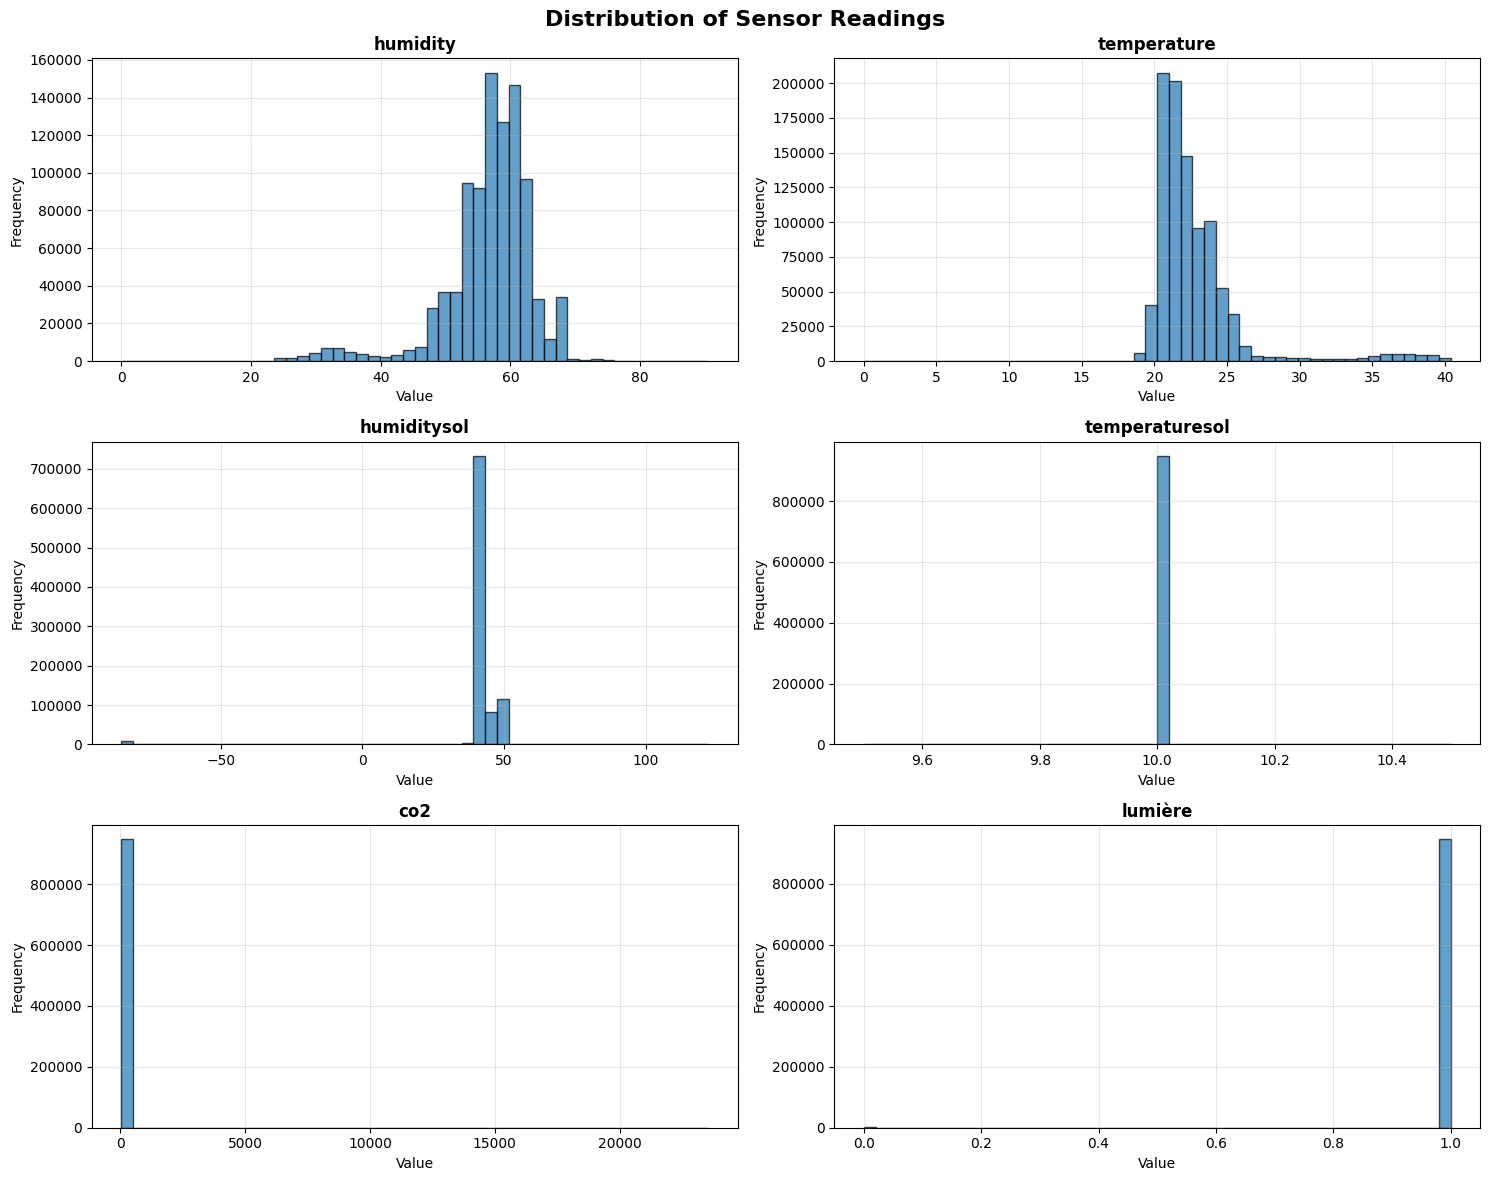

In [10]:
feature_cols = ['humidity', 'temperature', 'humiditysol', 'temperaturesol', 'co2', 'lumière']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Distribution of Sensor Readings', fontsize=16, fontweight='bold')

for idx, col in enumerate(feature_cols):
    ax = axes[idx//2, idx%2]
    ax.hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

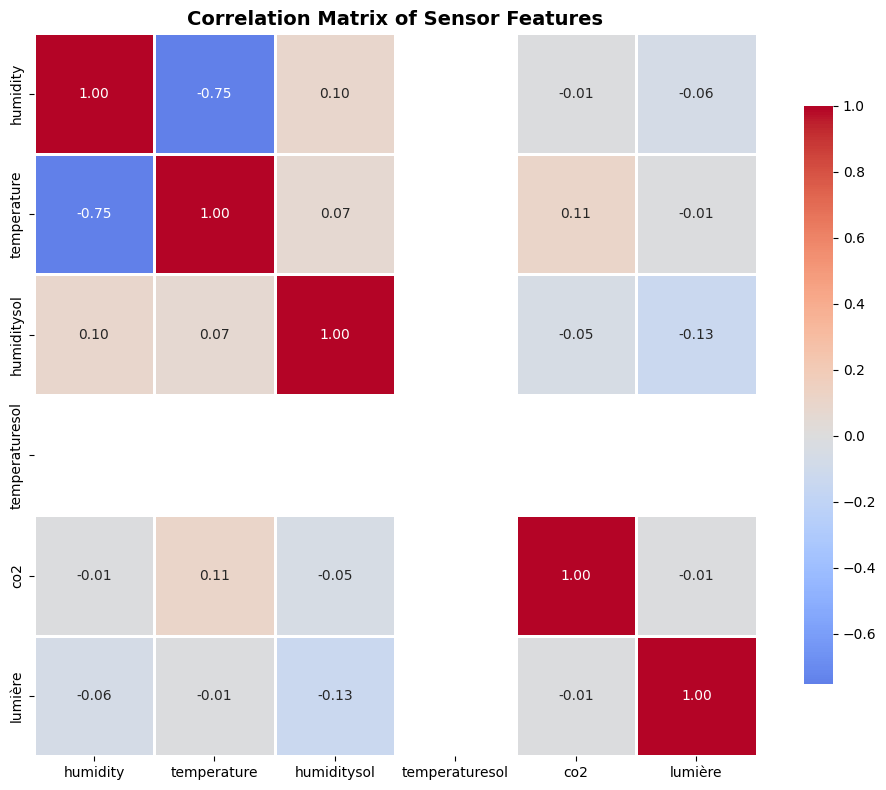


Correlation with target (humiditysol):
humiditysol       1.000000
humidity          0.095021
temperature       0.067896
co2              -0.051763
lumière          -0.132360
temperaturesol         NaN
Name: humiditysol, dtype: float64


In [11]:
df_clean = df[feature_cols].copy()
df_clean = df_clean.dropna()

correlation = df_clean.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Sensor Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCorrelation with target (humiditysol):")
print(correlation['humiditysol'].sort_values(ascending=False))

## 4. Data Preprocessing and Normalization

In [12]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_clean)

scaled_df = pd.DataFrame(scaled_data, columns=feature_cols)

print("Data normalized to range [0, 1]")
print(f"\nOriginal data shape: {df_clean.shape}")
print(f"Scaled data shape: {scaled_df.shape}")
print(f"\nScaled data statistics:")
scaled_df.describe()

Data normalized to range [0, 1]

Original data shape: (947682, 6)
Scaled data shape: (947682, 6)

Scaled data statistics:


,humidity,temperature,humiditysol,temperaturesol,co2,lumière
count,947682.000000,947682.000000,947682.000000,947682.0,947682.000000,947682.000000
mean,0.627209,0.565130,0.613310,0.0,0.002785,0.996942
std,0.074945,0.080636,0.063662,0.0,0.005214,0.055214
min,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,0.596685,0.519802,0.613527,0.0,0.002217,1.000000
50%,0.637569,0.542079,0.618357,0.0,0.002451,1.000000
75%,0.671823,0.584158,0.618357,0.0,0.003077,1.000000
max,1.000000,1.000000,1.000000,0.0,1.000000,1.000000


## 5. Create Time Series Sequences (Lookback Window = 15)

In [13]:
def create_sequences(data, lookback=15):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, 2])
    return np.array(X), np.array(y)

lookback = 15
X, y = create_sequences(scaled_data, lookback)

print(f"Sequences created with lookback window = {lookback}")
print(f"X shape: {X.shape} (samples, timesteps, features)")
print(f"y shape: {y.shape} (samples,)")
print(f"\nInput features per timestep: {X.shape[2]}")
print(f"Total sequences: {X.shape[0]:,}")

Sequences created with lookback window = 15
X shape: (947667, 15, 6) (samples, timesteps, features)
y shape: (947667,) (samples,)

Input features per timestep: 6
Total sequences: 947,667


## 6. Train-Test Split

In [14]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train-Test Split (80-20):")
print(f"\nTraining set:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"\nTest set:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

print(f"\nTraining samples: {len(X_train):,} ({(len(X_train)/len(X))*100:.1f}%)")
print(f"Test samples: {len(X_test):,} ({(len(X_test)/len(X))*100:.1f}%)")

Train-Test Split (80-20):

Training set:
  X_train: (758133, 15, 6)
  y_train: (758133,)

Test set:
  X_test: (189534, 15, 6)
  y_test: (189534,)

Training samples: 758,133 (80.0%)
Test samples: 189,534 (20.0%)


## 7. Save Preprocessed Data

In [15]:
import pickle
import os

results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

np.save(f'{results_dir}/X_train.npy', X_train)
np.save(f'{results_dir}/X_test.npy', X_test)
np.save(f'{results_dir}/y_train.npy', y_train)
np.save(f'{results_dir}/y_test.npy', y_test)

with open(f'{results_dir}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(f'{results_dir}/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("✅ Preprocessed data saved successfully!")
print(f"\nSaved files:")
print(f"  - X_train.npy: {X_train.shape}")
print(f"  - X_test.npy: {X_test.shape}")
print(f"  - y_train.npy: {y_train.shape}")
print(f"  - y_test.npy: {y_test.shape}")
print(f"  - scaler.pkl")
print(f"  - feature_names.pkl")

✅ Preprocessed data saved successfully!

Saved files:
  - X_train.npy: (758133, 15, 6)
  - X_test.npy: (189534, 15, 6)
  - y_train.npy: (758133,)
  - y_test.npy: (189534,)
  - scaler.pkl
  - feature_names.pkl


## Summary

**Data Preprocessing Complete!** ✅

### Key Statistics:
- **Original dataset:** ~947K samples
- **Features:** 6 sensor readings (humidity, temperature, soil moisture, soil temperature, CO2, illumination)
- **Target variable:** Soil moisture (humiditysol)
- **Preprocessing steps:**
  1. Missing value removal
  2. MinMaxScaler normalization [0,1]
  3. Time series sequences created (lookback=15)
  4. Train-test split (80-20)

### Next Steps:
**Notebook 02:** Build and train baseline LSTM model